# Détection de Fraude par Carte Bancaire
### *Credit Card Fraud Detection — Classification sur données déséquilibrées*

---

## Contexte

Ce projet analyse **284 807 transactions** de porteurs de cartes bancaires européens réalisées sur deux jours (septembre 2013). L'objectif est de construire un classifieur capable de détecter automatiquement les transactions frauduleuses.

Le principal défi est le **déséquilibre extrême des classes** : les fraudes représentent seulement **0,17 %** des transactions, ce qui rend l'accuracy inutilisable comme métrique et impose des stratégies de modélisation spécifiques.

---

## Description des variables

| Variable | Type | Description |
|---|---|---|
| `Time` | Float | Secondes écoulées depuis la 1ère transaction (index temporel relatif) |
| `V1` à `V28` | Float | Composantes issues d'une ACP sur les données originales (anonymisées) |
| `Amount` | Float | Montant de la transaction en euros |
| `Class` | Int | **Cible** — `0` : Légitime · `1` : Fraude |

> Les variables **V1–V28** résultent d'une Analyse en Composantes Principales (ACP) appliquée aux données brutes afin de protéger la confidentialité des porteurs. Leur interprétation directe n'est pas possible.

---

## Plan d'analyse

1. **Configuration & Imports**
2. **Chargement et inspection des données** — structure, qualité, déséquilibre
3. **Modèle naïf** — comprendre le piège de l'accuracy
4. **Gestion du déséquilibre** — undersampling, oversampling, pondération des classes
5. **Analyse Exploratoire (EDA)** — distributions, corrélations, features discriminantes
6. **Comparaison des modèles** — Logistic Regression, Decision Tree, RF, XGBoost, LightGBM

---

## 1. Configuration & Imports

Chargement des bibliothèques nécessaires à l'analyse, à la modélisation et à la visualisation.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
PALETTE = {'e': '#2ecc71', 'p': '#e74c3c'}

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Imports OK')

Imports OK


---

## 2. Chargement et Inspection des Données

In [30]:
df=pd.read_csv('Classic Datasets\creditcard.csv')

### 2.1 Aperçu des premières lignes

Les 5 premières lignes permettent de vérifier la structure du chargement, l'échelle des features et la présence de la variable cible `Class`.

In [31]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2.2 Structure et types des variables

Vérification du nombre d'entrées, des types de données et de l'utilisation mémoire.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### 2.3 Qualité des données — Valeurs manquantes

Un dataset sans valeur manquante ne nécessite pas d'imputation, ce qui simplifie le pipeline de prétraitement.

In [33]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### 2.4 Déséquilibre des classes

Le déséquilibre est la caractéristique la plus déterminante de ce dataset — il conditionne entièrement la stratégie de modélisation et le choix des métriques.

In [34]:
nombre_0=df['Class'].value_counts()[0]
nombre_1=df['Class'].value_counts()[1]
print(f'Nombre de transactions légitimes: {nombre_0}' )
print(f'qui est {nombre_0/(nombre_0+nombre_1)*100:.2f} % du total.')
print(f'Nombre de transactions frauduleuses: {nombre_1}' )
print(f'qui est {nombre_1/(nombre_0+nombre_1)*100:.2f} % du total.')

Nombre de transactions légitimes: 284315
qui est 99.83 % du total.
Nombre de transactions frauduleuses: 492
qui est 0.17 % du total.


---

## 3. Modèle Naïf — Le Piège de l'Accuracy

Avant d'appliquer des stratégies avancées, testons un `DecisionTreeClassifier` sans aucune gestion du déséquilibre pour illustrer concrètement le problème.

In [35]:
# Model simple
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

Train shape: (227845, 30), Test shape: (56962, 30)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.71      0.71        98

    accuracy                           1.00     56962
   macro avg       0.86      0.86      0.86     56962
weighted avg       1.00      1.00      1.00     56962

0.9990168884519505


> **Piège de l'accuracy** : un modèle qui prédit systématiquement *"Légitime"* pour chaque transaction obtient une accuracy de **99,83 %** — sans jamais détecter une seule fraude. L'accuracy est donc une métrique **trompeuse** sur ce dataset.

Les métriques adaptées aux classes déséquilibrées sont :

| Métrique | Description | Priorité |
|---|---|---|
| **Recall** | % de fraudes réellement détectées (TP / (TP + FN)) | Critique |
| **Précision** | % de vrais positifs parmi les alertes (TP / (TP + FP)) | Important |
| **F1-score** | Moyenne harmonique Précision / Recall | Métrique principale |
| **ROC-AUC** | Capacité de discrimination globale du modèle | Complémentaire |

## 4. Gestion du Déséquilibre des Classes

Il existe trois grandes familles de stratégies pour traiter le déséquilibre :

| Stratégie | Principe | Avantages | Inconvénients |
|---|---|---|---|
| **Undersampling** | Réduire la classe majoritaire | Simple, rapide | Perte d'information |
| **Oversampling** | Augmenter la classe minoritaire | Conserve toutes les données | Risque d'overfitting |
| **Méthodes combinées** | Suréchantillonnage + nettoyage | Meilleure frontière de décision | Coût computationnel élevé |
| **Pondération des classes** | Modifier la fonction de coût | Aucune modification des données | Paramètre à calibrer |

---

### 4.1 Sous-échantillonnage (Undersampling)

`RandomUnderSampler` réduit **aléatoirement** la classe majoritaire jusqu'à équilibre parfait. Rapide, mais on jette environ **283 800 observations légitimes** sur 284 315 — soit une perte massive d'information.

**Application** avec `imbalanced-learn` :

In [36]:
from imblearn.under_sampling import RandomUnderSampler

sampler = RandomUnderSampler()
X_res, y_res = sampler.fit_resample(X, y)

### 4.2 Sur-échantillonnage (Oversampling)

| Méthode | Principe |
|---|---|
| `RandomOverSampler` | Duplique des observations **existantes** de la classe minoritaire |
| **SMOTE** | Génère des points **synthétiques** par interpolation entre voisins proches |
| `ADASYN` | Variante de SMOTE — concentre la génération dans les zones difficiles à classifier |

**SMOTE** (*Synthetic Minority Over-sampling Technique*) est préféré à `RandomOverSampler` car il crée de *nouvelles* observations plausibles plutôt que de simplement dupliquer les existantes — ce qui réduit le risque de mémorisation parfaite par le modèle.

In [37]:
from imblearn.over_sampling import SMOTE

sampler = SMOTE()
X_res, y_res = sampler.fit_resample(X, y)

### 4.3 Méthodes combinées

| Méthode | Principe |
|---|---|
| `SMOTEENN` | SMOTE + nettoyage par **Edited Nearest Neighbours** |
| `SMOTETomek` | SMOTE + suppression des **paires de Tomek** (nettoyage des frontières de décision) |

Ces méthodes combinent génération synthétique et nettoyage de la frontière de décision. Elles produisent généralement de meilleures performances que SMOTE seul, au prix d'un coût computationnel plus élevé.

### Bonne pratique : Pipeline

L'échantillonnage **ne doit s'appliquer qu'au jeu d'entraînement**, jamais au jeu de test. L'intégrer dans un `Pipeline` garantit cette séparation automatiquement et prévient le **data leakage** — une erreur classique qui surestime les performances réelles du modèle.

In [38]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

model = Pipeline([
    ("smote", SMOTE()),
    ("dtc", DecisionTreeClassifier(random_state=42))
])

### 4.4 Stratification du split train/test

Le paramètre `stratify=y` dans `train_test_split` garantit que **chaque classe est représentée dans les mêmes proportions** dans les sets d'entraînement et de test.

Sans stratification sur ce dataset, le test set pourrait contenir très peu — voire aucune — fraude, rendant l'évaluation instable et non reproductible.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

| | Sans `stratify` | Avec `stratify=y` |
|---|---|---|
| Répartition | Aléatoire | Proportionnelle (≈ 99,83 % / 0,17 %) |
| Risque | Test set avec trop peu de fraudes | Répartition garantie et reproductible |
| Classes | Déséquilibre variable d'un run à l'autre | Déséquilibre stable et contrôlé |

> `stratify` **ne rééquilibre pas** les classes — il garantit uniquement que les proportions originales sont respectées dans chaque split.

### 4.5 Application complète — SMOTE + DecisionTreeClassifier

Test avec SMOTE appliqué **uniquement sur le train set**, puis évaluation sur le test set **original** (observations réelles, non synthétiques).

In [40]:
sampler = SMOTE()
X_res, y_res = sampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

0.9984963860506832


#### Vérification de l'équilibrage après SMOTE

Après rééchantillonnage, les deux classes doivent avoir exactement le même nombre d'observations dans `y_res`.

In [41]:
y_res.value_counts()

Class
0    284315
1    284315
Name: count, dtype: int64

### DecisionTreeClassifier

Le **`DecisionTreeClassifier`** permet de gérer le déséquilibre des classes via le paramètre **`class_weight`**.

#### Pondération automatique des classes

```python
DecisionTreeClassifier(
    class_weight="balanced"
)
```

* les poids sont calculés automatiquement à partir des fréquences des classes
* les erreurs sur la classe minoritaire sont davantage pénalisées
* la construction de l’arbre (Gini / entropie) est modifiée en conséquence


#### Pondération manuelle
```python
DecisionTreeClassifier(
    class_weight={0: 1, 1: 5}
)
```


### Random Forest

```python
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    class_weight="balanced"
)
```

Ou pondération manuelle :

```python
class_weight = {0: 1, 1: 5}
### XGBoost

XGBoost n'utilise pas `class_weight`, mais le **poids de la classe positive**.

```python
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight = n_negative / n_positive
)
```


### LightGBM

Deux options possibles :

#### Option 1 : automatique

```python
is_unbalance=True
```

#### Option 2 : explicite (recommandée)

```python
class_weight = {0: 1, 1: 5}
```


### CatBoost

#### Option 1 : poids automatiques

```python
auto_class_weights="Balanced"
```

#### Option 2 : poids explicites

```python
class_weights=[1, 5]
```



## Tableau récapitulatif

| Modèle                      | Équivalent de `class_weight="balanced"` |
| --------------------------- | --------------------------------------- |
| Decision Tree               | `class_weight="balanced"`               |
| Random Forest               | `class_weight="balanced"`               |
| XGBoost                     | `scale_pos_weight`                      |
| LightGBM                    | `class_weight` ou `is_unbalance`        |
| CatBoost                    | `auto_class_weights="Balanced"`         |
> La pondération des classes modifie la **fonction de coût**, pas les données.

---

## 5. Analyse Exploratoire des Données (EDA)

Avant toute modélisation, il est essentiel de comprendre la structure des données. Cette section explore :

| Visualisation | Objectif |
|---|---|
| Distribution des classes | Confirmer et quantifier le déséquilibre |
| Distribution du montant | Les fraudes ont-elles des montants caractéristiques ? |
| Distribution temporelle | Les fraudes se concentrent-elles à certaines heures ? |
| Features PCA | Quelles composantes séparent le mieux les deux classes ? |
| Δ Moyenne (Fraude − Légitime) | Quelles features sont les plus discriminantes ? |
| Boxplots | Visualiser les médianes et la dispersion par classe |
| Matrice de corrélation | Structure des relations entre variables |

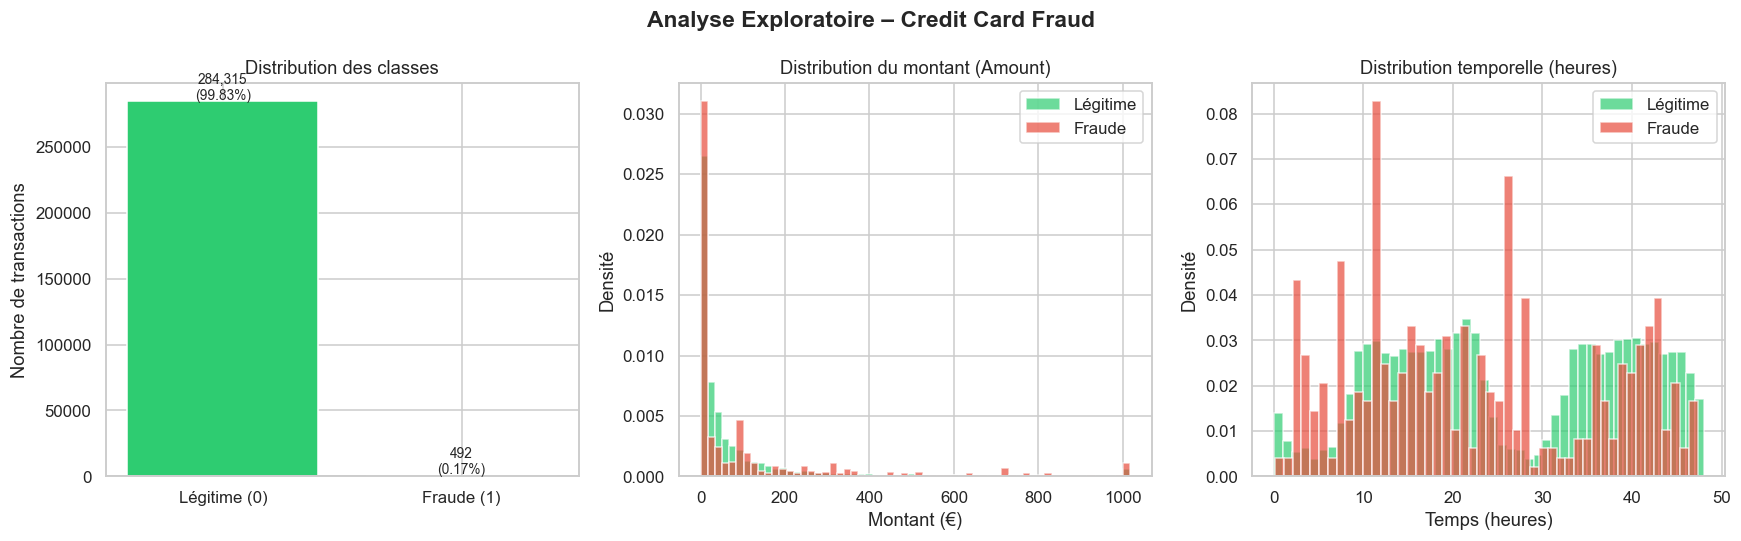

── Statistiques du montant par classe ──
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


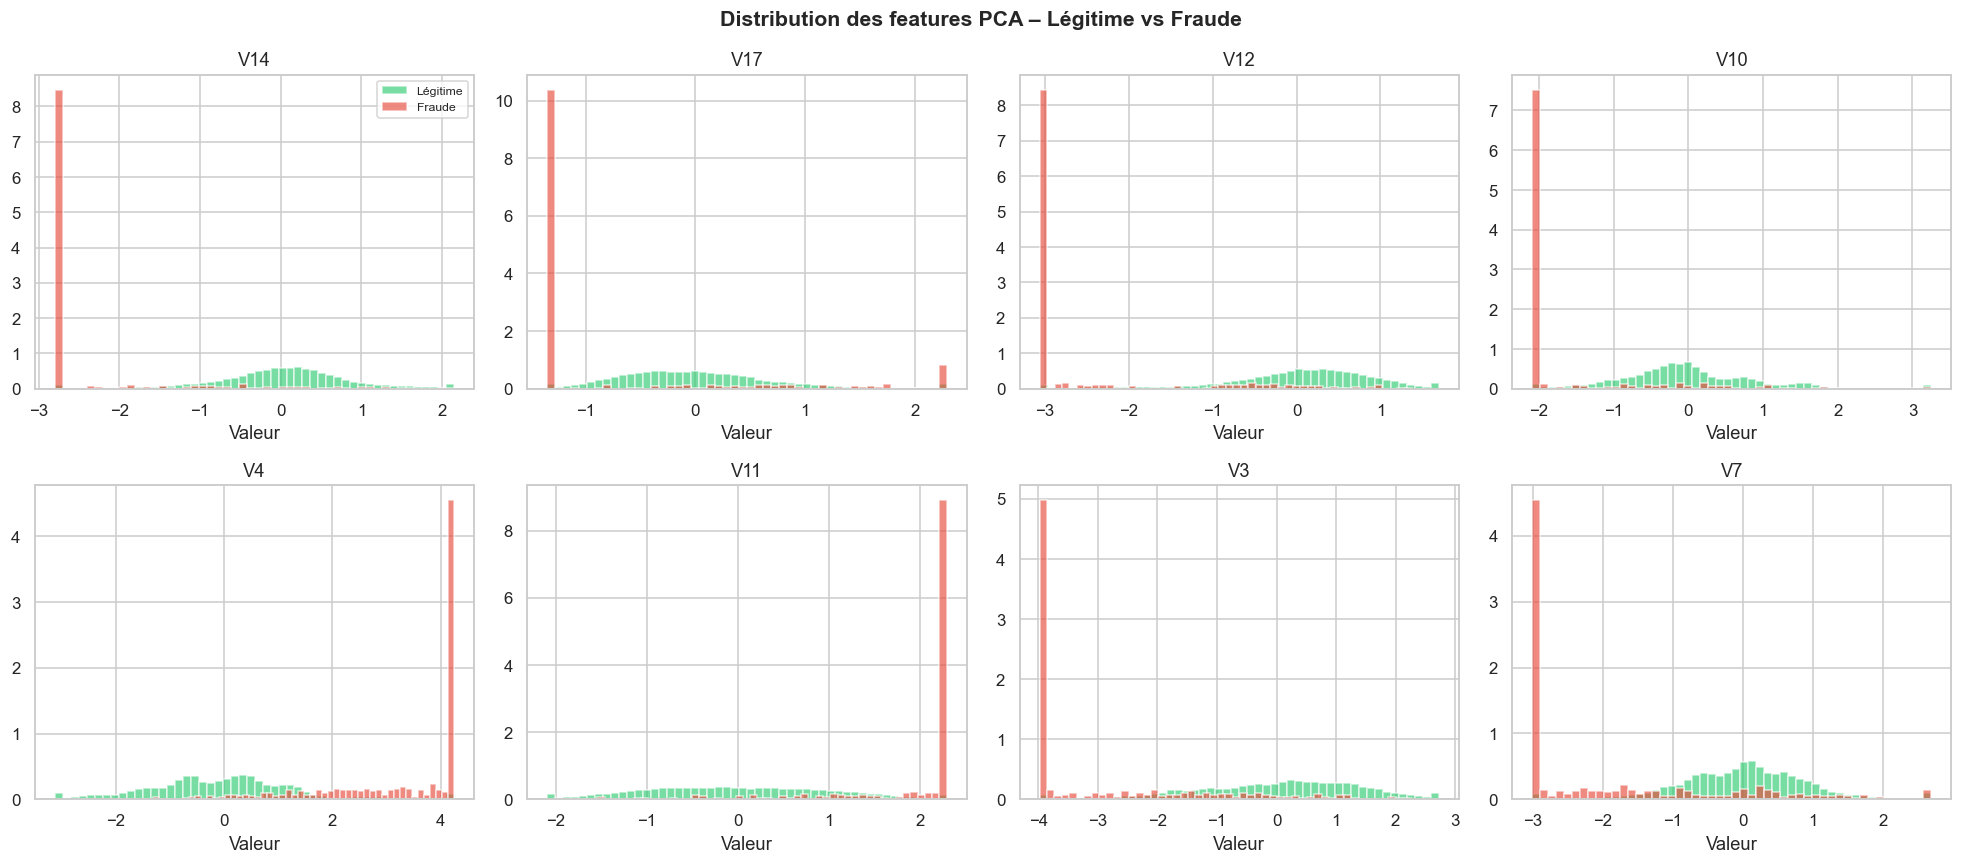

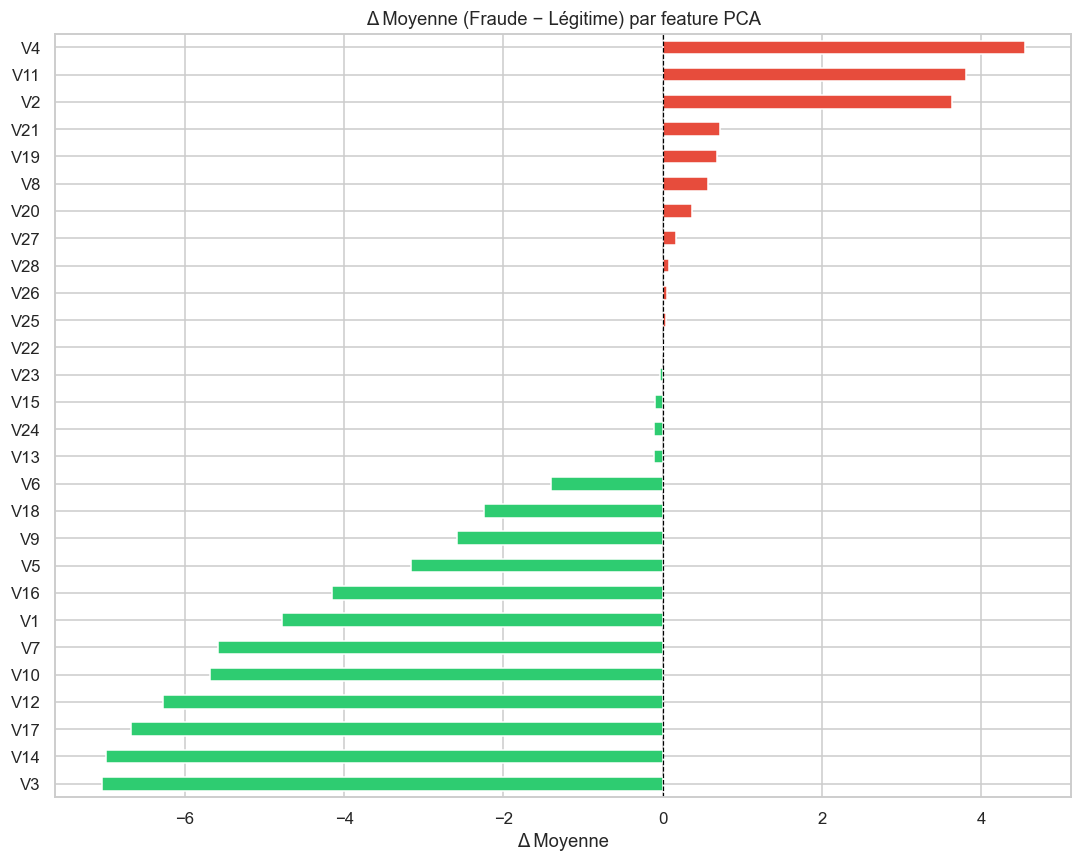

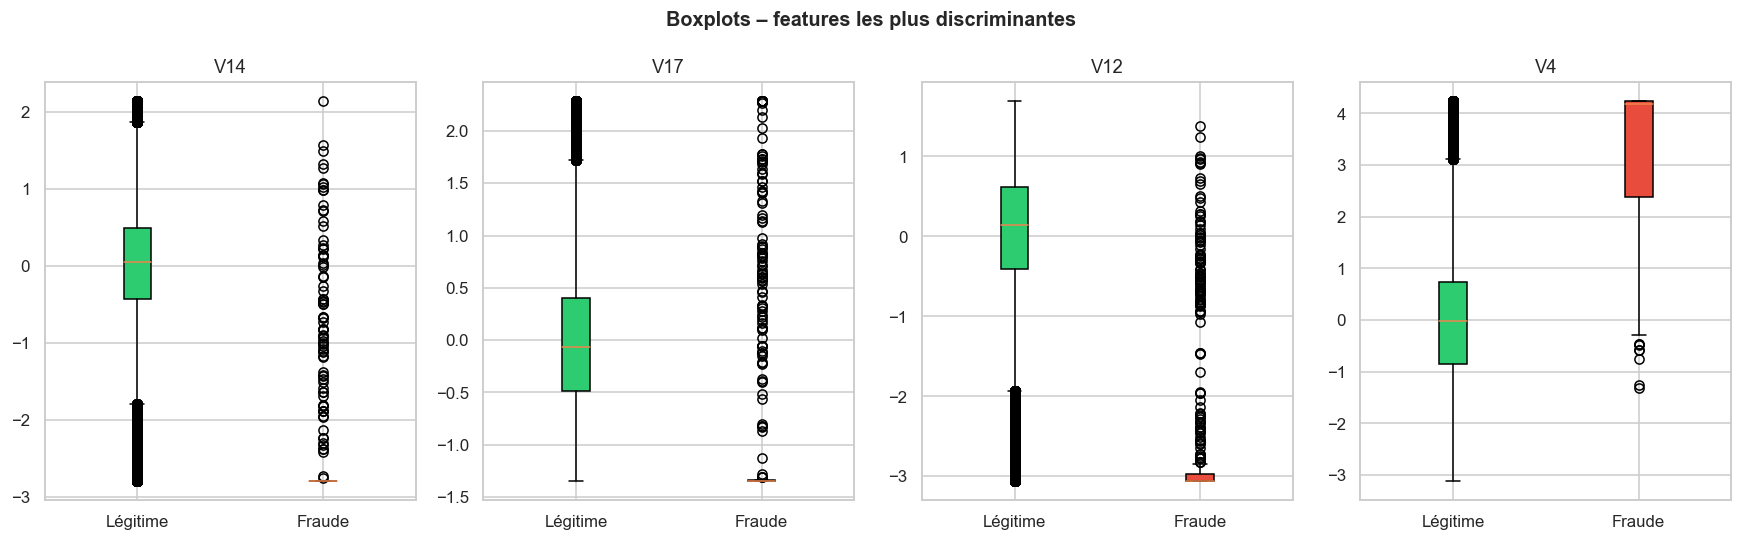

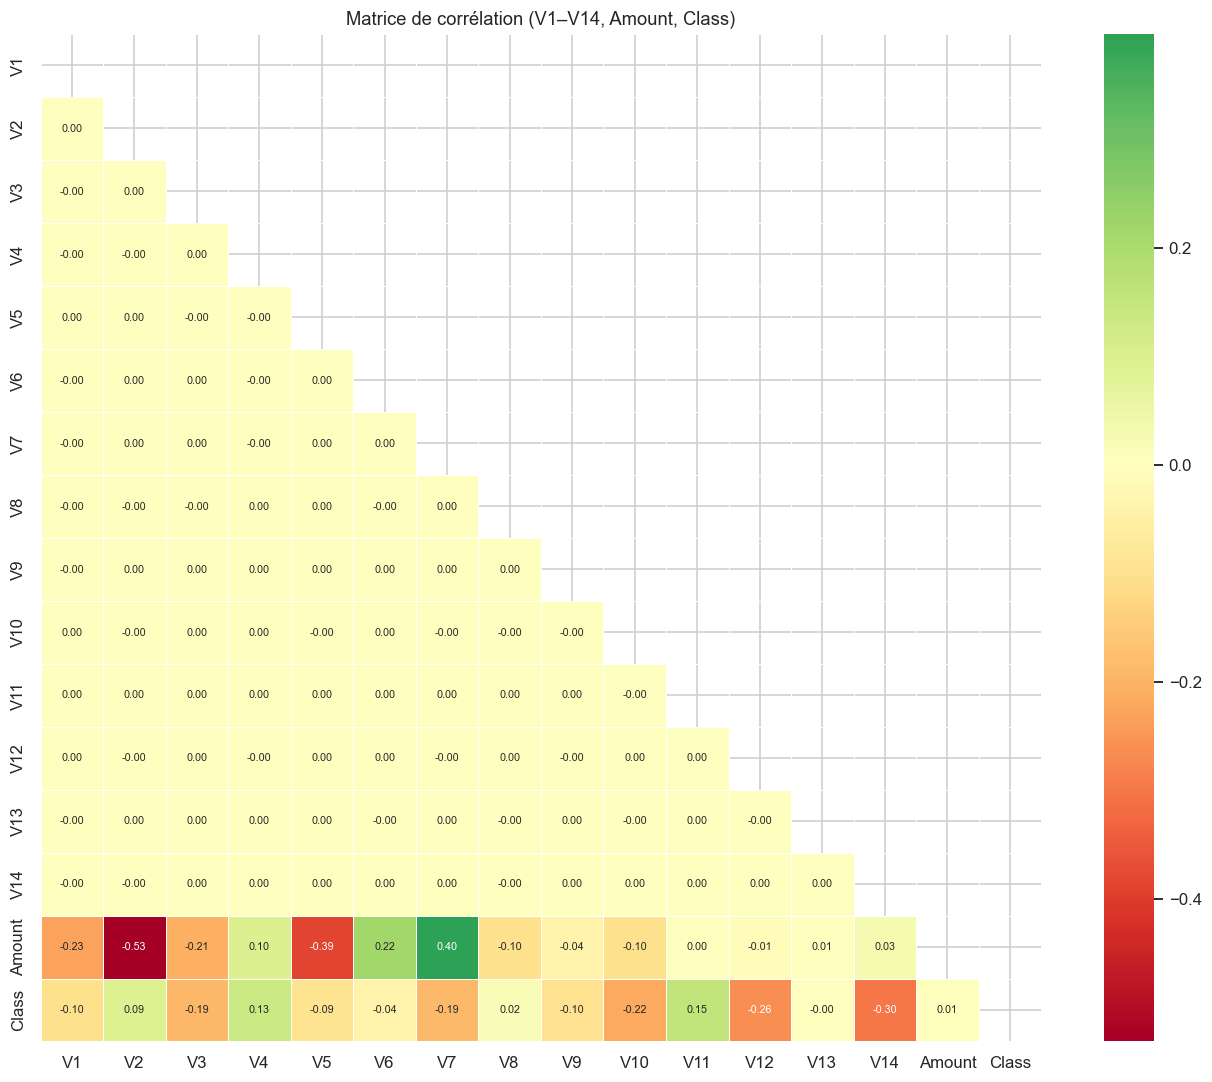

In [42]:
colors = ["#2ecc71", "#e74c3c"]

# ── 1. Class distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Analyse Exploratoire – Credit Card Fraud", fontsize=15, fontweight="bold")

counts = df["Class"].value_counts().sort_index()
axes[0].bar(["Légitime (0)", "Fraude (1)"], counts.values, color=colors, edgecolor="white")
axes[0].set_title("Distribution des classes")
axes[0].set_ylabel("Nombre de transactions")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1500, f"{v:,}\n({v/len(df)*100:.2f}%)", ha="center", fontsize=9)

# ── 2. Amount by class ────────────────────────────────────────────────────────
for cls, lbl, c in zip([0, 1], ["Légitime", "Fraude"], colors):
    sub = df[df["Class"] == cls]["Amount"].clip(upper=df["Amount"].quantile(0.99))
    axes[1].hist(sub, bins=60, alpha=0.7, label=lbl, color=c, density=True)
axes[1].set_title("Distribution du montant (Amount)")
axes[1].set_xlabel("Montant (€)")
axes[1].set_ylabel("Densité")
axes[1].legend()

# ── 3. Time by class ──────────────────────────────────────────────────────────
for cls, lbl, c in zip([0, 1], ["Légitime", "Fraude"], colors):
    sub = df[df["Class"] == cls]["Time"] / 3600
    axes[2].hist(sub, bins=48, alpha=0.7, label=lbl, color=c, density=True)
axes[2].set_title("Distribution temporelle (heures)")
axes[2].set_xlabel("Temps (heures)")
axes[2].set_ylabel("Densité")
axes[2].legend()

plt.tight_layout()
plt.show()

# ── Amount statistics by class ────────────────────────────────────────────────
print("── Statistiques du montant par classe ──")
print(df.groupby("Class")["Amount"].describe().round(2).to_string())

# ── 4. Top PCA features – distributions ──────────────────────────────────────
top_feats = ["V14", "V17", "V12", "V10", "V4", "V11", "V3", "V7"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distribution des features PCA – Légitime vs Fraude", fontsize=14, fontweight="bold")

for ax, feat in zip(axes.flatten(), top_feats):
    lo, hi = df[feat].quantile(0.01), df[feat].quantile(0.99)
    for cls, lbl, c in zip([0, 1], ["Légitime", "Fraude"], colors):
        sub = df[df["Class"] == cls][feat].clip(lo, hi)
        ax.hist(sub, bins=50, alpha=0.65, label=lbl, color=c, density=True)
    ax.set_title(feat)
    ax.set_xlabel("Valeur")
    if feat == "V14":
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── 5. Mean difference (fraud – legitimate) ───────────────────────────────────
mean_diff = (
    df.groupby("Class")
    .mean()
    .T
    .rename(columns={0: "Légitime", 1: "Fraude"})
)
mean_diff["Δ"] = mean_diff["Fraude"] - mean_diff["Légitime"]
delta = mean_diff["Δ"].drop(["Time", "Amount"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
bar_cols = ["#e74c3c" if x > 0 else "#2ecc71" for x in delta]
delta.plot(kind="barh", ax=ax, color=bar_cols, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Δ Moyenne (Fraude − Légitime) par feature PCA", fontsize=12)
ax.set_xlabel("Δ Moyenne")
plt.tight_layout()
plt.show()

# ── 6. Boxplots – most discriminating features ────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Boxplots – features les plus discriminantes", fontsize=13, fontweight="bold")

for ax, feat in zip(axes, ["V14", "V17", "V12", "V4"]):
    lo, hi = df[feat].quantile(0.01), df[feat].quantile(0.99)
    data_bp = [
        df[df["Class"] == 0][feat].clip(lo, hi),
        df[df["Class"] == 1][feat].clip(lo, hi),
    ]
    bp = ax.boxplot(data_bp, patch_artist=True, labels=["Légitime", "Fraude"])
    bp["boxes"][0].set_facecolor("#2ecc71")
    bp["boxes"][1].set_facecolor("#e74c3c")
    ax.set_title(feat)

plt.tight_layout()
plt.show()

# ── 7. Correlation heatmap (PCA features + Amount) ────────────────────────────
corr_cols = [f"V{i}" for i in range(1, 15)] + ["Amount", "Class"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.4, ax=ax, annot_kws={"size": 7}
)
ax.set_title("Matrice de corrélation (V1–V14, Amount, Class)", fontsize=12)
plt.tight_layout()
plt.show()


---

## 6. Comparaison des Modèles

### Stratégie de modélisation

| Étape | Choix technique |
|---|---|
| **Normalisation** | `RobustScaler` sur `Amount` et `Time` — robuste aux outliers |
| **Gestion du déséquilibre** | `class_weight="balanced"` (sklearn) · `scale_pos_weight` (XGBoost) |
| **Split** | 80 % train / 20 % test, stratifié |
| **Évaluation** | Sur le test set réel (sans données synthétiques) |

### Métriques d'évaluation

| Métrique | Formule | Importance |
|---|---|---|
| **Recall** | TP / (TP + FN) | Critique — manquer une fraude a un coût élevé |
| **Précision** | TP / (TP + FP) | Important — trop de fausses alarmes = friction client |
| **F1-score** | 2 × P × R / (P + R) | Métrique principale de comparaison |
| **ROC-AUC** | Aire sous la courbe ROC | Capacité de discrimination globale |

> L'**accuracy** n'est **pas** utilisée comme critère de comparaison — elle dépasse 99 % même pour un modèle ne détectant aucune fraude.

### Modèles comparés

| Modèle | Type | Gestion du déséquilibre |
|---|---|---|
| **Dummy** | Baseline | Prédit toujours la classe majoritaire |
| **Logistic Regression** | Linéaire | `class_weight="balanced"` |
| **Decision Tree** | Arborescent | `class_weight="balanced"`, `max_depth=8` |
| **Random Forest** | Ensemble (bagging) | `class_weight="balanced"`, 100 arbres |
| **XGBoost** | Ensemble (boosting) | `scale_pos_weight = n_neg / n_pos` |
| **LightGBM** | Ensemble (boosting) | `class_weight="balanced"` |

Train: 227,451 légitimes | 394 fraudes  →  scale_pos_weight=577.3
  Dummy
  Logistic Regression
  Decision Tree
  Random Forest
  XGBoost
  LightGBM

── Résultats (triés par F1) ──
                     Precision  Recall      F1  ROC-AUC  Accuracy
Model                                                            
XGBoost                 0.8817  0.8367  0.8586   0.9682    0.9995
LightGBM                0.8485  0.8571  0.8528   0.9624    0.9995
Random Forest           0.9605  0.7449  0.8391   0.9529    0.9995
Decision Tree           0.0693  0.8265  0.1279   0.9075    0.9806
Logistic Regression     0.0609  0.9184  0.1141   0.9720    0.9755
Dummy                   0.0000  0.0000  0.0000   0.5000    0.9983


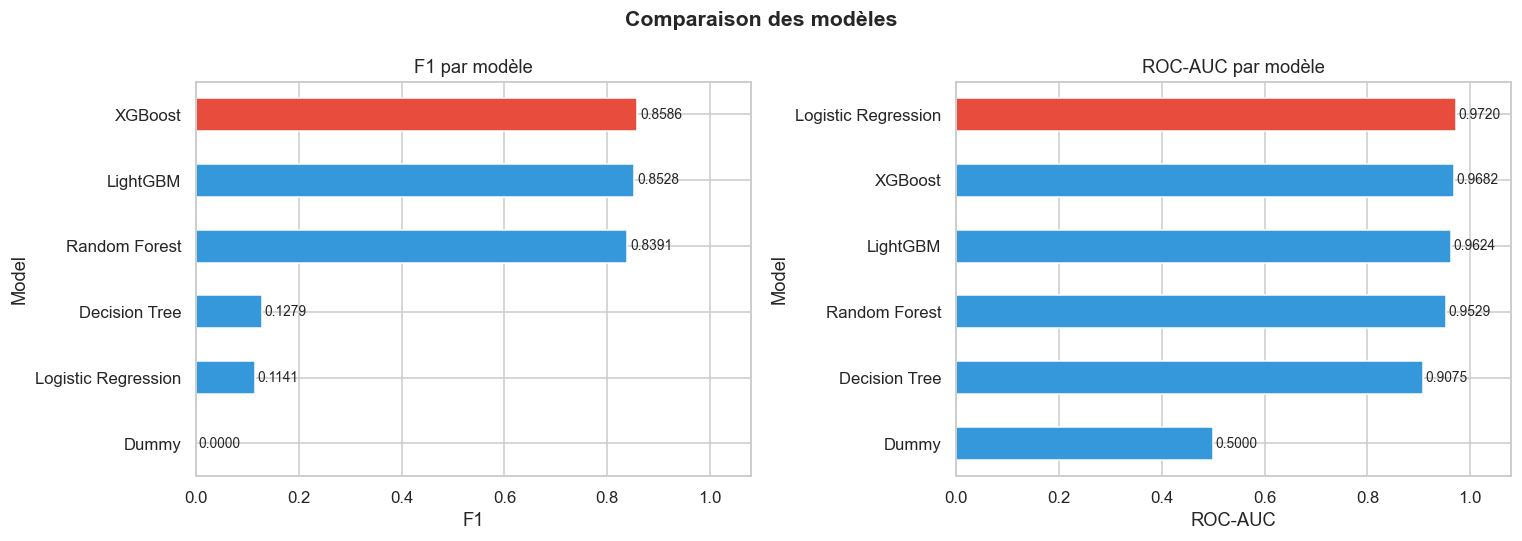

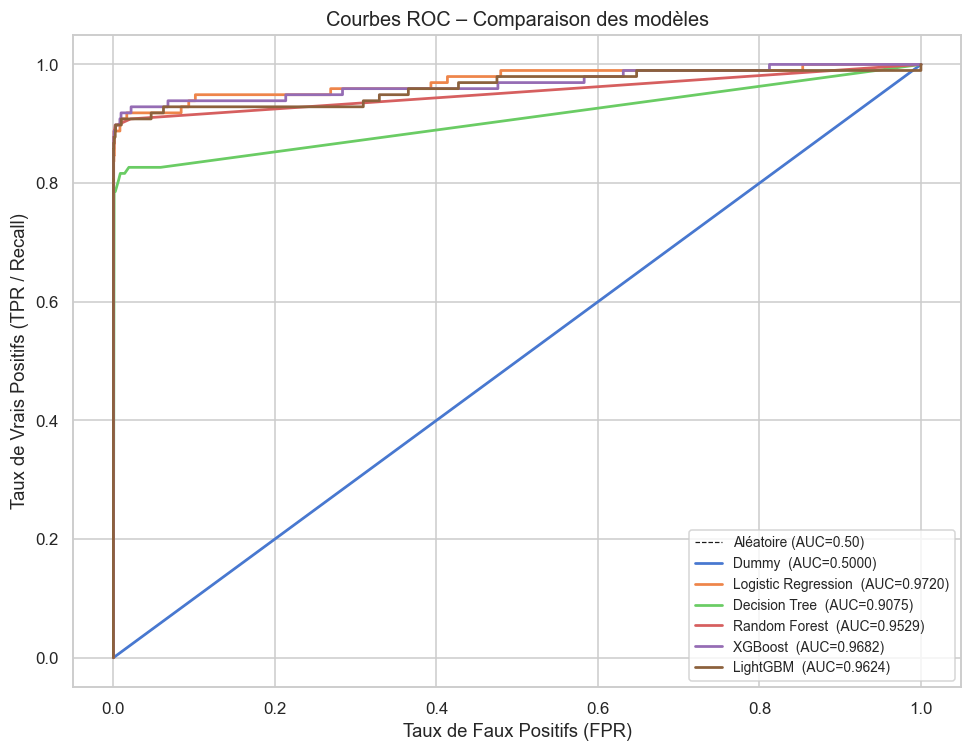

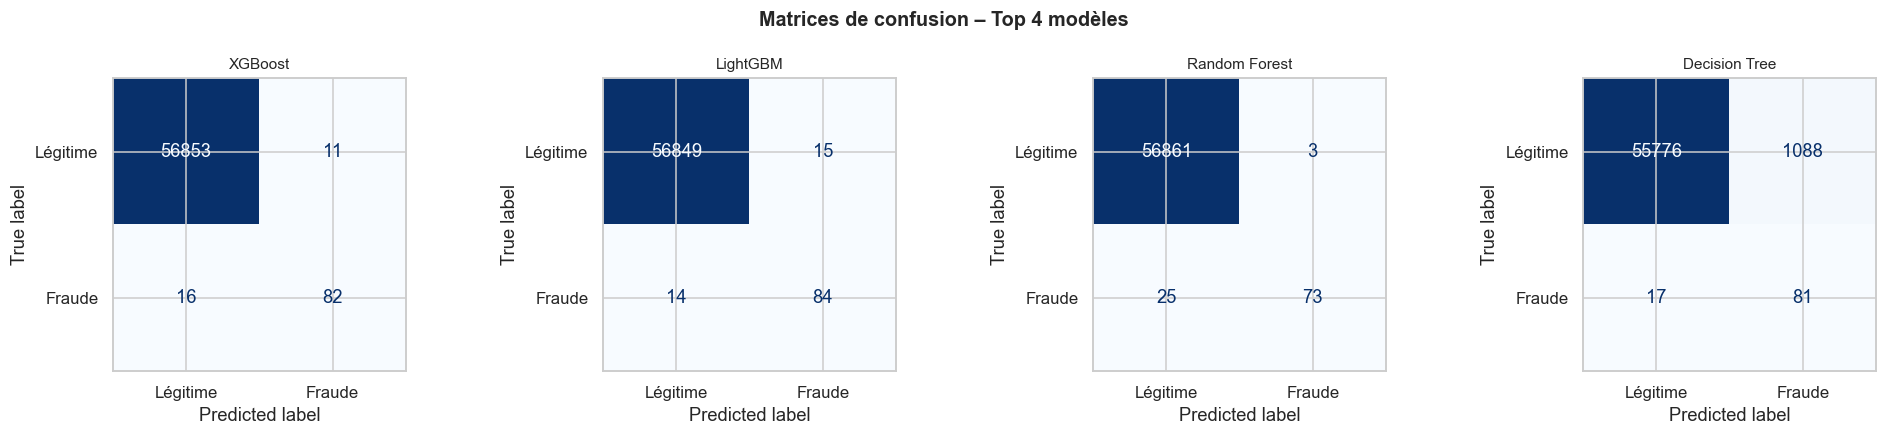

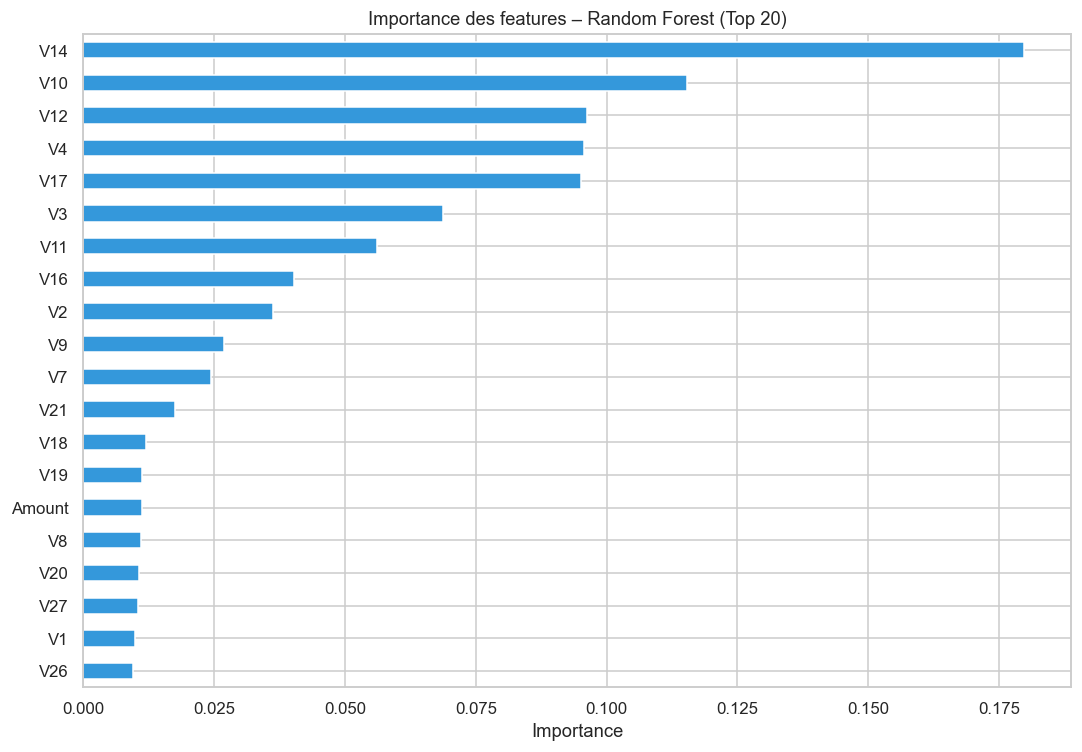


Meilleur modèle (F1): XGBoost
   F1      = 0.8586
   Recall  = 0.8367
   ROC-AUC = 0.9682

              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [43]:
from sklearn.metrics import precision_score
from sklearn.preprocessing import RobustScaler

# ── Preprocessing ─────────────────────────────────────────────────────────────
X = df.drop('Class', axis=1).copy()
y = df['Class']

scaler = RobustScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos = n_neg / n_pos
print(f"Train: {n_neg:,} légitimes | {n_pos} fraudes  →  scale_pos_weight={scale_pos:.1f}")

# ── Model zoo ─────────────────────────────────────────────────────────────────
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced", max_depth=8, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos, eval_metric="logloss",
        random_state=RANDOM_STATE, verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
    ),
}

# ── Train & evaluate ──────────────────────────────────────────────────────────
results = []
trained = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else None

    results.append({
        "Model":     name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
        "Accuracy":  accuracy_score(y_test, y_pred),
    })
    trained[name] = (clf, y_pred, y_prob)
    print(f"  {name}")

results_df = pd.DataFrame(results).set_index("Model").sort_values("F1", ascending=False)
print("\n── Résultats (triés par F1) ──")
print(results_df.round(4).to_string())

# ── Bar chart: F1 & ROC-AUC ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison des modèles", fontsize=14, fontweight="bold")

for ax, metric in zip(axes, ["F1", "ROC-AUC"]):
    vals = results_df[metric].dropna().sort_values()
    bar_colors = ["#e74c3c" if v == vals.max() else "#3498db" for v in vals]
    vals.plot(kind="barh", ax=ax, color=bar_colors, edgecolor="white")
    ax.set_title(f"{metric} par modèle")
    ax.set_xlabel(metric)
    ax.set_xlim(0, 1.08)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aléatoire (AUC=0.50)")

for name, (_, _, y_prob) in trained.items():
    if y_prob is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=1.8, label=f"{name}  (AUC={auc:.4f})")

ax.set_xlabel("Taux de Faux Positifs (FPR)")
ax.set_ylabel("Taux de Vrais Positifs (TPR / Recall)")
ax.set_title("Courbes ROC – Comparaison des modèles", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# ── Confusion matrices – top 4 models ────────────────────────────────────────
top4 = results_df.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Matrices de confusion – Top 4 modèles", fontsize=13, fontweight="bold")

for ax, name in zip(axes, top4):
    _, y_pred_m, _ = trained[name]
    cm = confusion_matrix(y_test, y_pred_m)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Légitime", "Fraude"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

# ── Feature importance – Random Forest ────────────────────────────────────────
rf_clf = trained["Random Forest"][0]
importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Importance des features – Random Forest (Top 20)", fontsize=12)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────────
best = results_df["F1"].idxmax()
print(f"\nMeilleur modèle (F1): {best}")
print(f"   F1      = {results_df.loc[best, 'F1']:.4f}")
print(f"   Recall  = {results_df.loc[best, 'Recall']:.4f}")
print(f"   ROC-AUC = {results_df.loc[best, 'ROC-AUC']:.4f}")
print(f"\n{classification_report(y_test, trained[best][1], target_names=['Légitime', 'Fraude'])}")
